Problem Statement

This dataset was created to analyze all shows available on Amazon Prime Video, enabling us to extract valuable insights such as:

Content Diversity: Which genres and categories dominate the platform?

Regional Availability: How does content distribution vary across different regions and categories?

Trends Over Time: How has Amazon Prime’s content library evolved over the years?

IMDb Ratings and Popularity: Which shows are the highest-rated and most popular on the platform?

In [1]:
# Import important libraries as part of the project

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

In [4]:
# Fetch 1st dataset
df1 = pd.read_csv("titles.csv.zip")

In [5]:
# Fetch 2nd dataset

df2  = pd.read_csv("credits.csv.zip")

In [8]:
# showing the columns of dataset 1 i.e titles

df1.columns

Index(['id', 'title', 'type', 'description', 'release_year',
       'age_certification', 'runtime', 'genres', 'production_countries',
       'seasons', 'imdb_id', 'imdb_score', 'imdb_votes', 'tmdb_popularity',
       'tmdb_score'],
      dtype='object')

In [9]:
# showing the columns of dataset 2 i.e credits

df2.columns

Index(['person_id', 'id', 'name', 'character', 'role'], dtype='object')

In [10]:
# merge dataset 1 and dataset 2 with the common column id

data = pd.merge(df1, df2, on='id')

In [11]:
# print the merged data

data

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score,person_id,name,character,role
0,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'f...",['US'],26.0,tt0850645,8.6,1092.0,15.424,7.6,59401,Joe Besser,Joe,ACTOR
1,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'f...",['US'],26.0,tt0850645,8.6,1092.0,15.424,7.6,31460,Moe Howard,Moe,ACTOR
2,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'f...",['US'],26.0,tt0850645,8.6,1092.0,15.424,7.6,31461,Larry Fine,Larry,ACTOR
3,tm19248,The General,MOVIE,"During America’s Civil War, Union spies steal ...",1926,NaN,78,"['action', 'drama', 'war', 'western', 'comedy'...",['US'],NaN,tt0017925,8.2,89766.0,8.647,8.0,21174,Buster Keaton,Johnny Gray,ACTOR
4,tm19248,The General,MOVIE,"During America’s Civil War, Union spies steal ...",1926,NaN,78,"['action', 'drama', 'war', 'western', 'comedy'...",['US'],NaN,tt0017925,8.2,89766.0,8.647,8.0,28713,Marion Mack,Annabelle Lee,ACTOR
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124342,tm1054116,Baikunth,MOVIE,"This story is about prevalent caste problem, e...",2021,NaN,72,"['family', 'drama']",[],NaN,tt14331982,8.4,49.0,0.645,NaN,1938589,Sangam Shukla,Madhav,ACTOR
124343,tm1054116,Baikunth,MOVIE,"This story is about prevalent caste problem, e...",2021,NaN,72,"['family', 'drama']",[],NaN,tt14331982,8.4,49.0,0.645,NaN,1938565,Vijay Thakur,Sanjay Thakur,ACTOR
124344,tm1054116,Baikunth,MOVIE,"This story is about prevalent caste problem, e...",2021,NaN,72,"['family', 'drama']",[],NaN,tt14331982,8.4,49.0,0.645,NaN,728899,Vanya Wellens,Budhiya,ACTOR
124345,tm1054116,Baikunth,MOVIE,"This story is about prevalent caste problem, e...",2021,NaN,72,"['family', 'drama']",[],NaN,tt14331982,8.4,49.0,0.645,NaN,1938620,Vishwa Bhanu,Gissu,ACTOR


In [12]:
# Checking the rows and columns count in the merged dataset

data.shape

(124347, 19)

In [13]:
# Checking all columns in the merged dataset

data.columns

Index(['id', 'title', 'type', 'description', 'release_year',
       'age_certification', 'runtime', 'genres', 'production_countries',
       'seasons', 'imdb_id', 'imdb_score', 'imdb_votes', 'tmdb_popularity',
       'tmdb_score', 'person_id', 'name', 'character', 'role'],
      dtype='object')

In [14]:
# Merged dataset information

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 124347 entries, 0 to 124346
Data columns (total 19 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    124347 non-null  object 
 1   title                 124347 non-null  object 
 2   type                  124347 non-null  object 
 3   description           124256 non-null  object 
 4   release_year          124347 non-null  int64  
 5   age_certification     56707 non-null   object 
 6   runtime               124347 non-null  int64  
 7   genres                124347 non-null  object 
 8   production_countries  124347 non-null  object 
 9   seasons               8153 non-null    float64
 10  imdb_id               119044 non-null  object 
 11  imdb_score            118296 non-null  float64
 12  imdb_votes            118272 non-null  float64
 13  tmdb_popularity       124332 non-null  float64
 14  tmdb_score            114082 non-null  float64
 15  

Data Cleaning
Handling Missing or Null Values

In [16]:
# Checking null values in the merged dataset

data.isnull().sum()

id                           0
title                        0
type                         0
description                 91
release_year                 0
age_certification        67640
runtime                      0
genres                       0
production_countries         0
seasons                 116194
imdb_id                   5303
imdb_score                6051
imdb_votes                6075
tmdb_popularity             15
tmdb_score               10265
person_id                    0
name                         0
character                16307
role                         0
dtype: int64

The 'description' column has null values. To handle null values, let's drop the null values.

In [18]:
#Drop null values from description column
data.dropna(subset=['description'], inplace=True)

In [19]:
#Replacing all null values of age certification with the most frequently occuring value through mode
data['age_certification'].fillna(data['age_certification'].mode()[0], inplace=True)

In [20]:
#Replacing null values in season column with 0
data['seasons'].fillna(0, inplace=True)

In [21]:
#Drop null values from imdb_id as imdb_id is unique for movies and TV shows
data.dropna(subset=['imdb_id'], inplace=True)
     

In [22]:
#Replacing null values in imdb_score column with the mean of imdb_score
data['imdb_score'].fillna(round(data['imdb_score'].mean(),1), inplace=True)

In [23]:
data.shape

(119022, 19)

In [24]:
#Replacing null values in imdb_votes column with 0
data['imdb_votes'].fillna(0, inplace=True)

In [25]:
#Replacing null values in tmdb_popularity column with the mean of tmdb_popularity
data['tmdb_popularity'].fillna(round(data['tmdb_popularity'].mean(),1), inplace=True)

In [26]:
#Replacing null values in tmdb_score with the mean
data['tmdb_score'].fillna(round(data['tmdb_score'].mean(),1), inplace=True)

In [27]:
#Replacing null values in character column with 'unknown' as we don't know who played the character
data['character'].fillna('unknown', inplace=True)
     

In [28]:
data.isnull().sum()
     

id                      0
title                   0
type                    0
description             0
release_year            0
age_certification       0
runtime                 0
genres                  0
production_countries    0
seasons                 0
imdb_id                 0
imdb_score              0
imdb_votes              0
tmdb_popularity         0
tmdb_score              0
person_id               0
name                    0
character               0
role                    0
dtype: int64

In [29]:

#checking the rows and columns of dataset after data cleaning process
data.shape

(119022, 19)

Handling Duplicate values

In [30]:
#Checking duplicate values
data.duplicated().sum()
     

np.int64(168)

We have 168 duplicate values in our dataset. So we will drop these duplicate values to avoid any data redundancy issue.

In [31]:
#Dropping all duplicate values from the dataset
data.drop_duplicates(inplace=True)

In [32]:
data.duplicated().sum()

np.int64(0)

In [33]:
#Checking the datatypes of our dataset
data.dtypes
     

id                       object
title                    object
type                     object
description              object
release_year              int64
age_certification        object
runtime                   int64
genres                   object
production_countries     object
seasons                 float64
imdb_id                  object
imdb_score              float64
imdb_votes              float64
tmdb_popularity         float64
tmdb_score              float64
person_id                 int64
name                     object
character                object
role                     object
dtype: object

In [34]:
#Checking the statistical description of the dataset
data.describe()

,release_year,runtime,seasons,imdb_score,imdb_votes,tmdb_popularity,tmdb_score,person_id
count,118854.000000,118854.000000,118854.000000,118854.000000,1.188540e+05,118854.000000,118854.000000,1.188540e+05
mean,1995.694592,96.054453,0.153466,5.968800,2.312887e+04,10.334858,5.997704,3.976869e+05
std,28.010517,29.798646,1.006917,1.238147,8.819975e+04,40.786345,1.252196,5.549632e+05
min,1912.000000,1.000000,0.000000,1.100000,0.000000e+00,0.000164,0.800000,1.000000e+00
25%,1980.000000,83.000000,0.000000,5.200000,2.790000e+02,1.917000,5.400000,3.821300e+04
50%,2009.000000,94.000000,0.000000,6.000000,1.227000e+03,3.960000,6.000000,1.323810e+05
75%,2017.000000,109.000000,0.000000,6.800000,7.040000e+03,8.924000,6.800000,5.633935e+05
max,2022.000000,328.000000,49.000000,9.900000,1.133692e+06,1437.906000,10.000000,2.371153e+06


As the dataset is cleaned and ready for further analysis. Let's recap what we did

1. Data loading and merging: Load the dataset into the environment and merged on the basis of common column i.e 'id'.

2. Handling missing or null values: Handle the missing or null values inside our dataset

Null values in 'description' and 'imdb_id' column were dropped.
Null values in 'age certification' is replaced with mode.
Null values in 'seasons', 'imdb_votes' and character' were replaced with '0', '0' and 'unknown' respectively.
Null values in 'imdb_score' and 'tmdb_score' were replaced with their respective means.
3. Handling duplicate values: Identified duplicate values and dropped it from the dataset

Data Visualization
Data visualization is the graphical representation of information and data. By using different types of charts, maps and graphs visualization tool helps us to identify the patterns, trends and outliers in the data.

1. Content Type Distribution (TV Shows vs Movies)

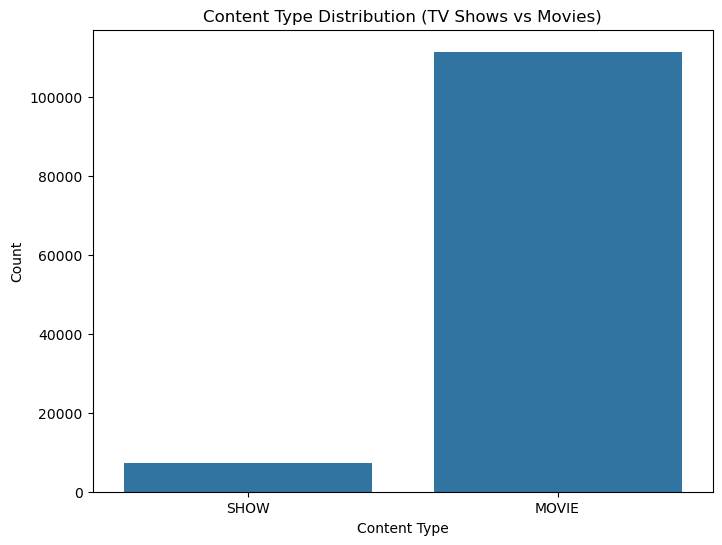

In [38]:
# Visual representation of content type distribution using countplot
plt.figure(figsize=(8, 6))
sns.countplot(data=data, x='type')
plt.title('Content Type Distribution (TV Shows vs Movies)')
plt.xlabel('Content Type')
plt.ylabel('Count')
plt.show()

Findings

As you can see clearly that the content type 'Movie' is dominated. This suggests Amazon prime prioritizes licensing or producing standalone films over episodic content.

Text(0.5, 1.0, 'Top 10 Genres in Amazon Prime')

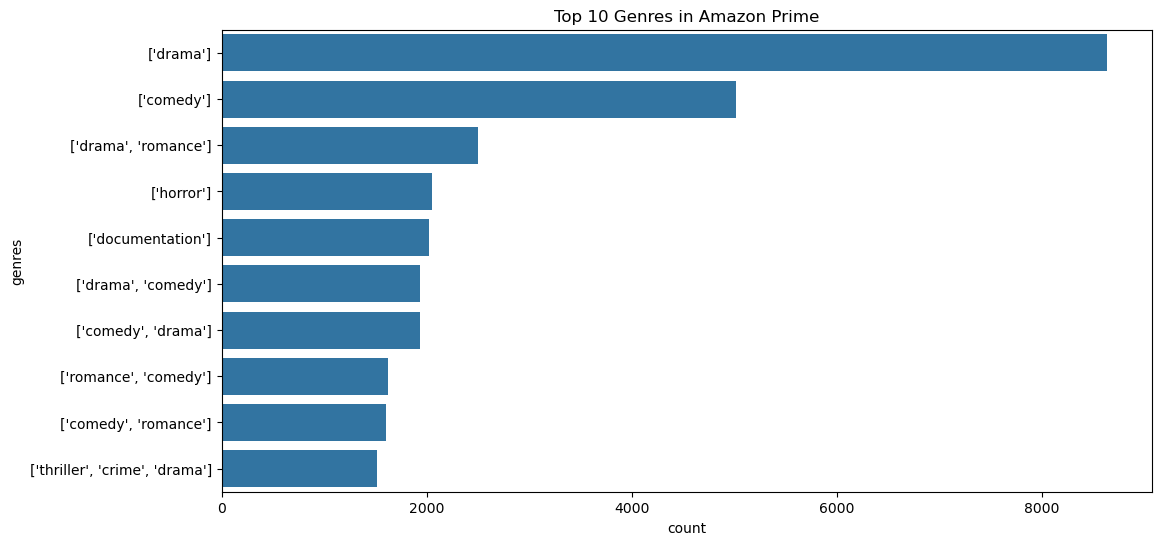

In [39]:
# Visual representation of top 10 genres in Amazon Prime using barplot
plt.figure(figsize=(12, 6))
sns.countplot(data=data, y='genres', order=data['genres'].value_counts().index[:10])
plt.title('Top 10 Genres in Amazon Prime')

Findings

Drama and comedy are leading as the most represented genres. These genres cater to a wide global audience, explaining their higher frequency.

Text(0, 0.5, 'Frequency')

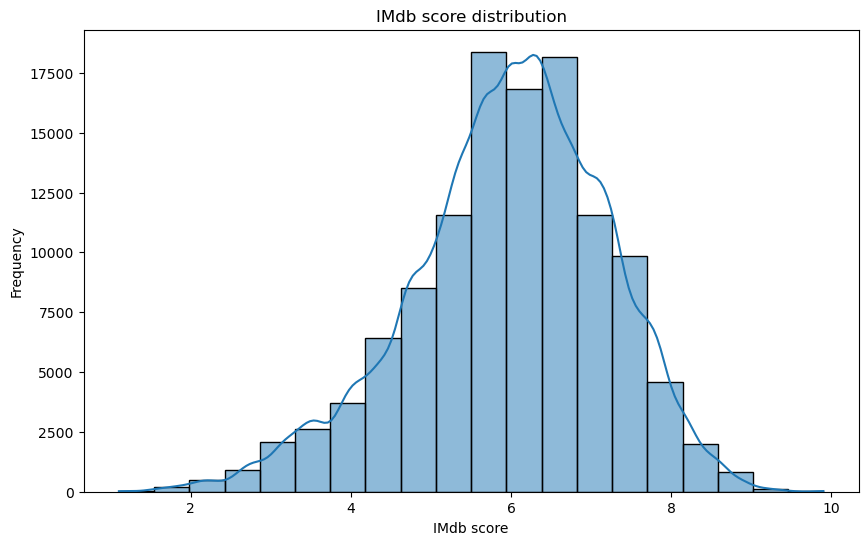

In [40]:

# Visual representation of IMdb score distribution using histogram
plt.figure(figsize=(10, 6))
sns.histplot(data['imdb_score'], bins=20, kde=True)
plt.title('IMdb score distribution')
plt.xlabel('IMdb score')
plt.ylabel('Frequency')
     

4. Yearly release trend

Text(0, 0.5, 'Number of releases')

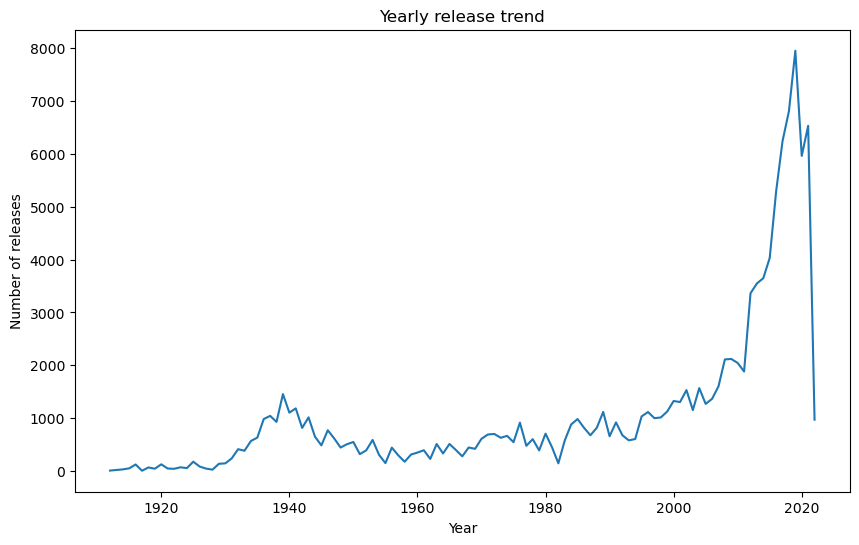

In [42]:

# Visual representation of yearly release trend using line plot
plt.figure(figsize=(10, 6))
sns.lineplot(data=data['release_year'].value_counts().sort_index())
plt.title('Yearly release trend')
plt.xlabel('Year')
plt.ylabel('Number of releases')

Findings

We can observe clearly that there is some notable increase in the release trend after 2015 followed by the peak around 2018-2020.
This interpretation tells that amazon is trying to push more towards original content and global streaming expansion.

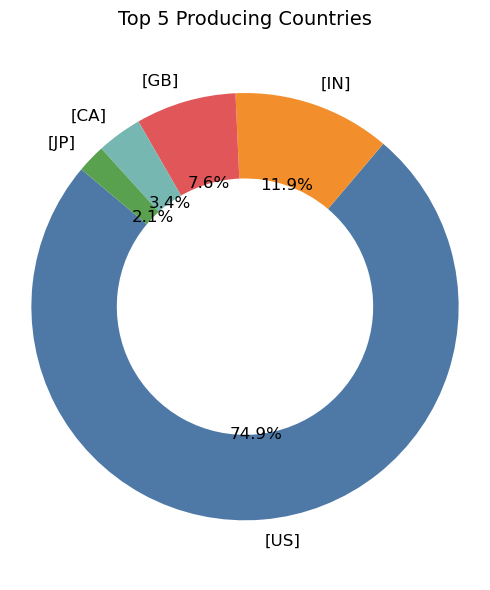

In [47]:
# Analyze top production countries using pie chart
colors = ['#4e79a7', '#f28e2b', '#e15759', '#76b7b2', '#59a14f']

# Strip brackets and quotes using string cleanup

top_countries = data['production_countries'].value_counts().head(5)
top_countries.index = top_countries.index.str.replace(r"[']", "", regex=True)

# Pie chart

plt.figure(figsize=(5, 6))
top_countries.plot.pie(
    autopct='%1.1f%%',
    colors=colors,
    startangle=140,
    textprops={'fontsize': 12},
    wedgeprops=dict(width=0.4)  # Optional: donut-style for readability
)
plt.title("Top 5 Producing Countries", fontsize=14)
plt.ylabel("")
plt.axis('equal')  # Keeps pie chart circular
plt.tight_layout()
plt.show()

Findings

We can see that more than 50% of the content comes from USA with significant contributions in UK, Canada and India respectively.
This concentration shows a western-centric content catalog with some international reach.

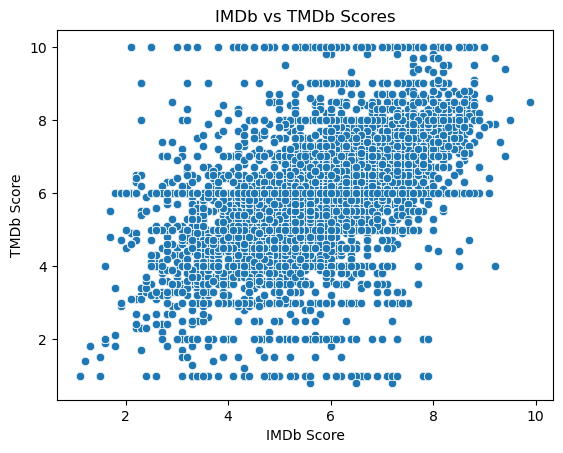

In [49]:

# Comparison of IMDb score vs TMDb score using scatter plot
sns.scatterplot(x='imdb_score', y='tmdb_score', data=data)
plt.title("IMDb vs TMDb Scores")
plt.xlabel("IMDb Score")
plt.ylabel("TMDb Score")
plt.show()
     

Findings

A moderate to strong positive correlation is visible indicating that well recieved-titles on IMdb perform similar on TMdb as well.
However, a few points fall off the line, highlighting some rating inconsistencies across platforms.

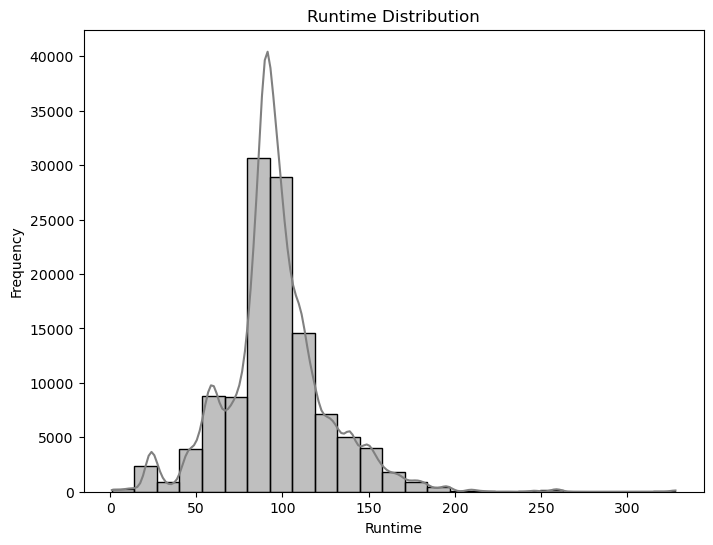

In [50]:
# Analyzing the runtime of Movies and TV shows using histogram
plt.figure(figsize=(8, 6))
sns.histplot(data= data, x= 'runtime', bins= 25, color= 'grey', kde='true')
plt.title('Runtime Distribution')
plt.xlabel('Runtime')
plt.ylabel('Frequency')
plt.show()
     

Findings

The peak of the histogram is around 70-90 minutes. This indicates that the runtime for most common movies and TV shows on amazon prime is ranging between 70 to 90 minutes.
The distribution is rightly skewed having longer tail on the right side of the peak.
Considering the fact that there are more number of movies and TV shows fall between 60 to 100 minutes. This might be the sweet spot for most viewers and creators as it strikes a balance between storytelling and viewer engagement.

Text(0.5, 1.0, 'Role-wise Distribution')

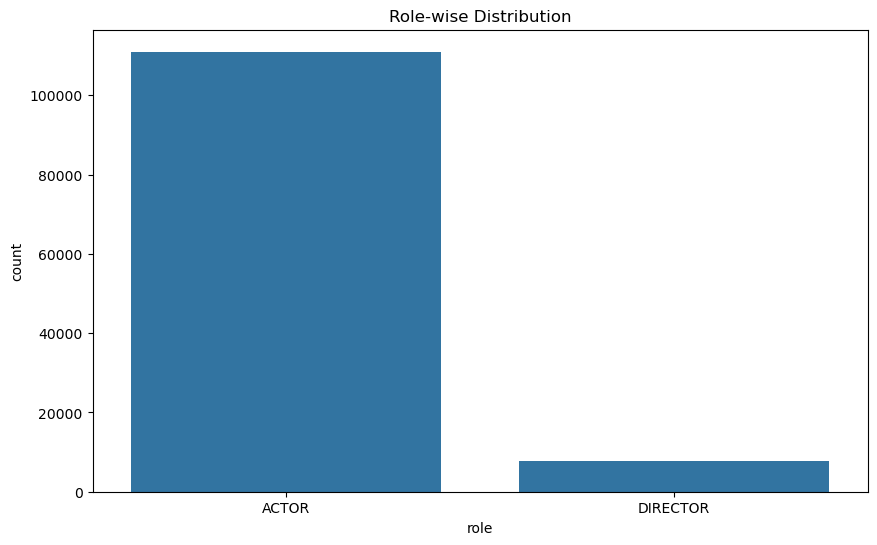

In [52]:
# Analyzing the role-wise distribution using countplot
plt.figure(figsize=(10, 6))
sns.countplot(data=data, x='role', order=data['role'].value_counts().index)
plt.title('Role-wise Distribution')
     

Findings

It is clearly observed that actor records more than director in the movies. Most of the amazon prime movies have actors as compared to the directors.

Text(0.5, 0, 'Seasons')

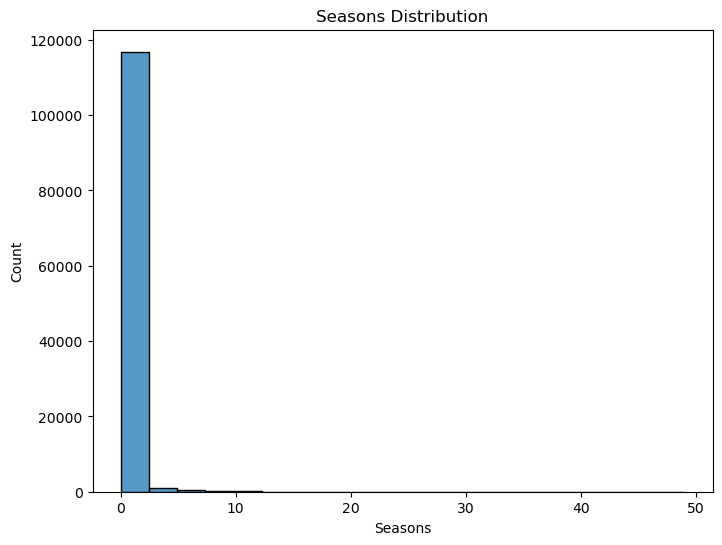

In [54]:
# Analyzing the number of seasons using histogram
plt.figure(figsize=(8, 6))
sns.histplot(data= data, x= 'seasons', bins= 20)
plt.title('Seasons Distribution')
plt.xlabel('Seasons')

Findings

The histogram shows peak around 1 constitutes that seasons are only applicable to TV shows not movies.
Most of the TV shows on amazon prime have 1 to 3 seasons. This results that many TV shows don't continue for more number of seasons.

Text(0.5, 1.0, 'Age Certification Distribution')

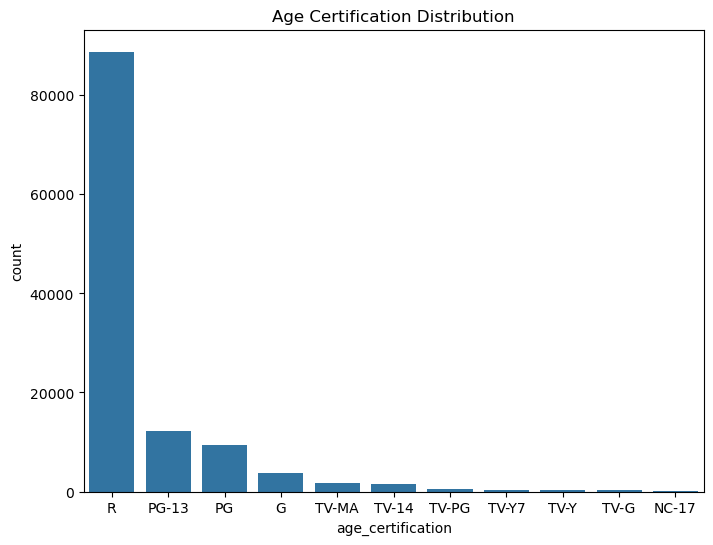

In [55]:
# Representation of age certification using bar plot
plt.figure(figsize=(8, 6))
sns.countplot(data=data, x='age_certification', order=data['age_certification'].value_counts().index)
plt.title('Age Certification Distribution')

Findings

‘R’ rated content dominates the catalog by a large margin, making up the overwhelming majority of titles, which indicates Amazon Prime hosts a significant amount of content intended for mature audiences.
Movies or TV shows having PG-13 certification are at 2nd position. Parents might find these kind of movies inappropriate for younger children whose age is below 13 years.
Hence it is derived that most of the production companies can make movies with 'R' certification as these movies get a good response from viewers.

Text(0.5, 1.0, 'Average Ratings for Each Age Certification')

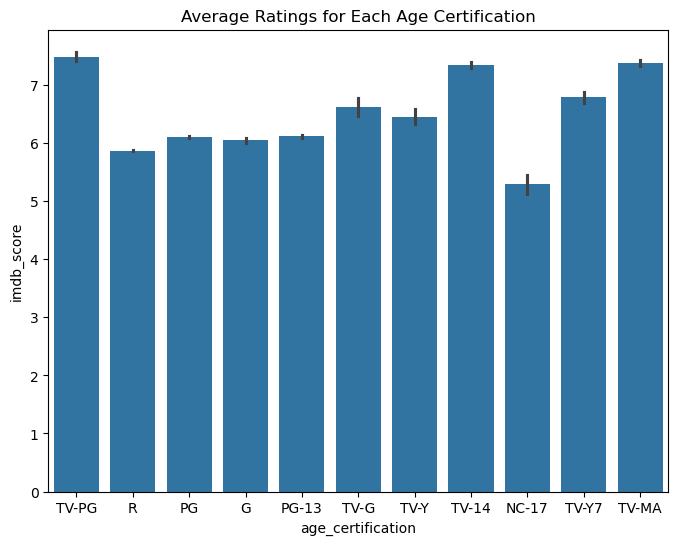

In [56]:
# Representation of average ratings for each age certification using barplot
plt.figure(figsize=(8, 6))
sns.barplot(data=data, x='age_certification', y='imdb_score')
plt.title('Average Ratings for Each Age Certification')
     

Findings

TV-PG, TV-MA, and TV-14 certified content have the highest average IMDb ratings, all scoring above 7.0, indicating strong audience reception for content targeted at general or mature television audiences.
This bar plot representation highlights viewer preferences on the basis of age certifications. The content with higher ratings are inclined towards mature titles.

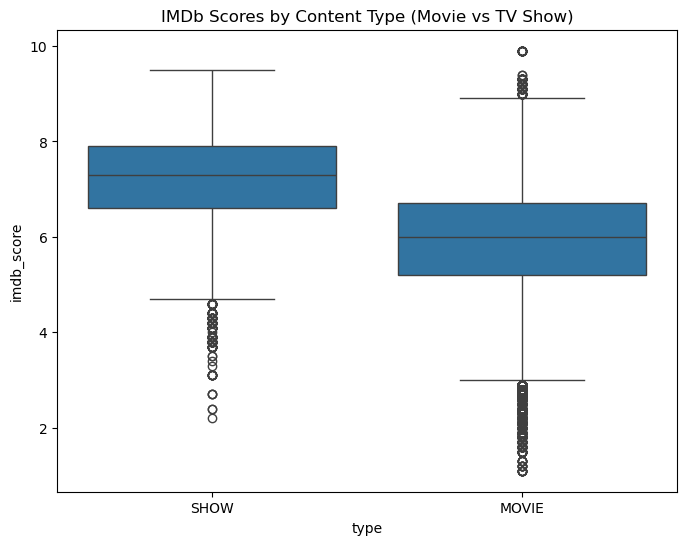

In [57]:
# Analysis of IMDb scores by content type using box plot
plt.figure(figsize=(8, 6))
sns.boxplot(data=data, x='type', y='imdb_score')
plt.title('IMDb Scores by Content Type (Movie vs TV Show)')
plt.show()
     

Findings

TV shows tend to have slightly higher median IMDb scores and tighter score ranges, suggesting consistent viewer satisfaction.
Movies exhibit more variability and outliers, indicating mixed audience reception.

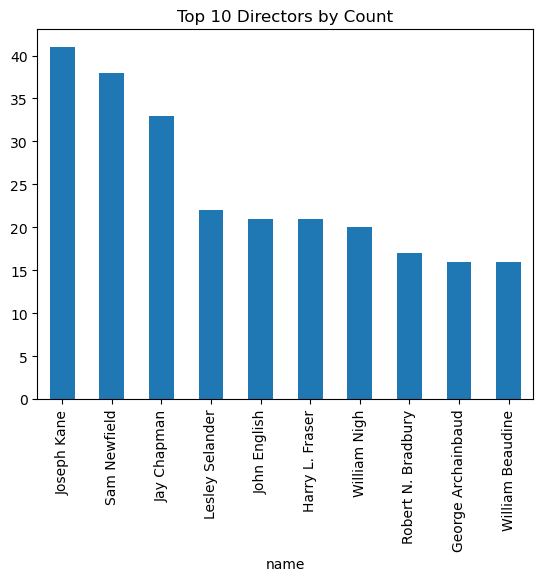

In [59]:
# Analyzing top directors with most credits using bar plot
directors = data[data['role'] == 'DIRECTOR']['name'].value_counts().head(10)
directors.plot(kind='bar')
plt.title("Top 10 Directors by Count")
plt.show()
     


Findings

Joseph Kane leads the list with the highest number of directed titles, shows his extensive contribution to Amazon's prime content catalog.
Directors like Sam Newfield and Jay Chapman also appear prominently, suggesting these individuals have either worked on series with many episodes or have consistently produced content featured on the platform.

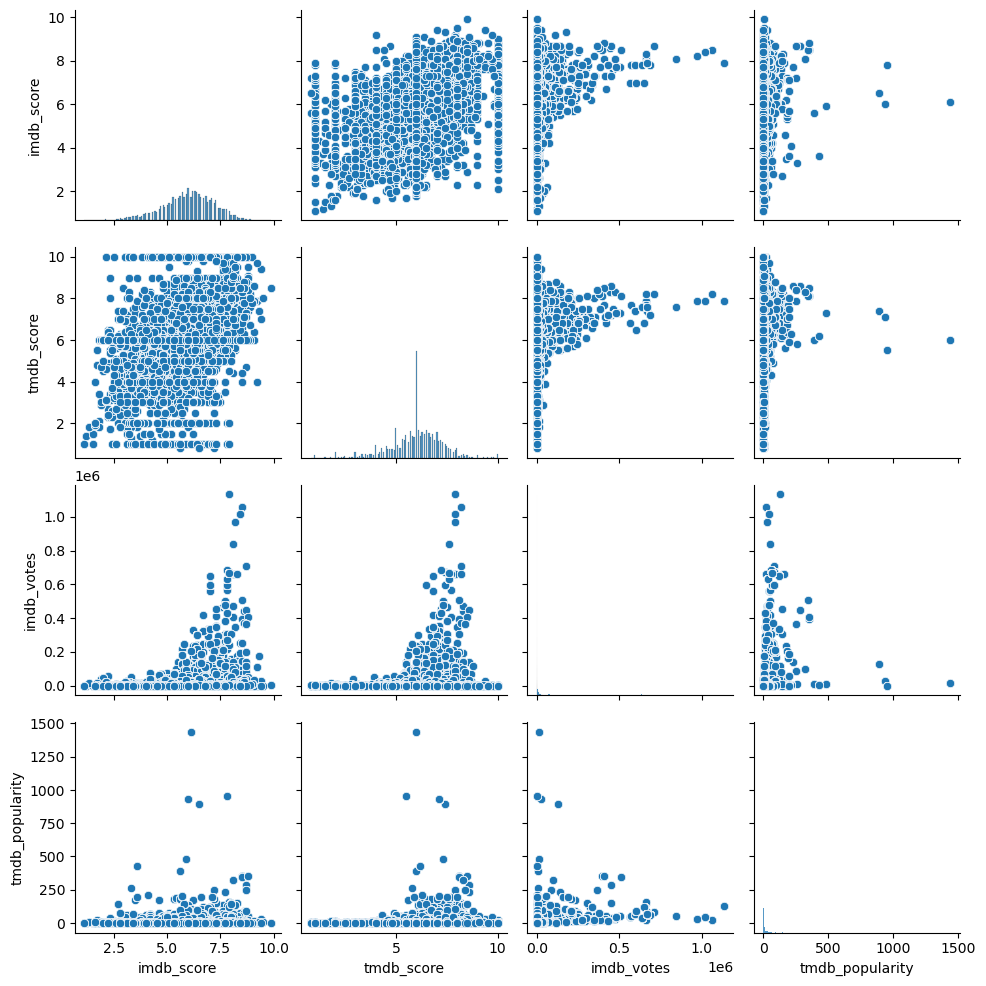

In [60]:
# Analyzing pair-wise relationship between rating variables using pairplot
sns.pairplot(data[['imdb_score', 'tmdb_score', 'imdb_votes','tmdb_popularity']])
plt.show()
     

Findings

Moderate Positive correlation --> IMDb score and IMDb votes show a moderate positive relationship, indicating that titles with higher ratings tend to receive more viewer engagement, though there are exceptions with many low-rated yet highly voted titles as well.
Loosely correlation --> TMDb score and IMDb score appear loosely correlated, suggesting some consistency in user perception across both platforms, but not strongly enough.
Not strongly correlation --> TMDb popularity does not strongly correlate with either IMDb votes or scores, implying that "popularity" on TMDb is influenced by additional factors like search trends, recentness, or promotional activity rather than pure audience rating metrics.

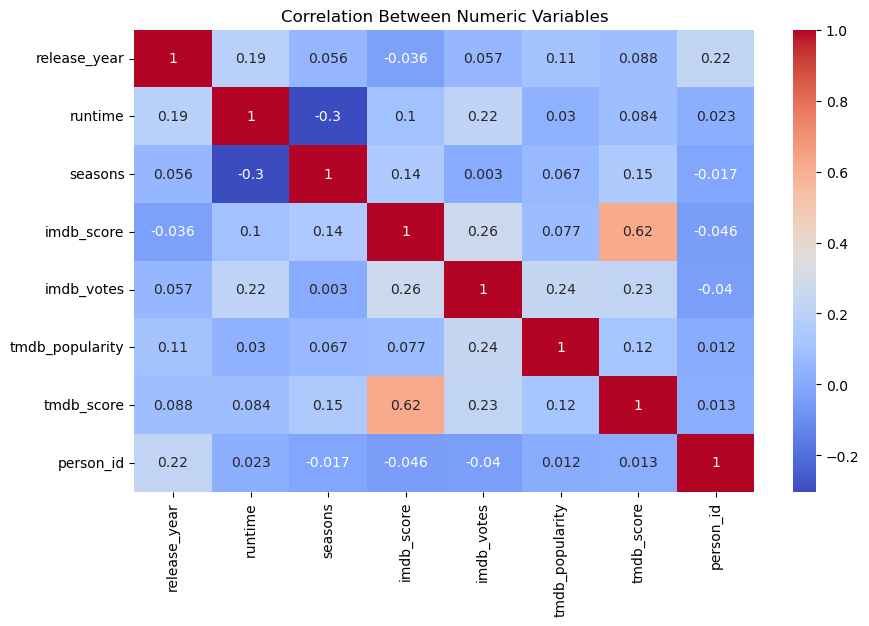

In [61]:
# Analyze the heatmap correlation between different numeric variables
plt.figure(figsize=(10,6))
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Between Numeric Variables")
plt.show()

Findings

Here 1 means strong or perfect positive correlation and -0.2 means negative or weak correlation
In this heatmap, it can be clearly observed that the relationship between imdb_score and tmdb_score is strong positive correlation.
But on the other side, runtime and seasons are negative correlated to each other.